# Creating event dataset for scenario reconstruction from CICIDS2017

## 1.1 - Preliminary actions

### 1.1.1 - Validate downloaded files

In [34]:
import os
print(os.getcwd())
for root, dirs, files in os.walk('./CSVs'):
        print(root+":")
        if dirs:
            print('\n'.join(dirs))
        if files:
            print('\n'.join(files))

/home/users/davide.zhang/Attack Scenario Reconstruction
./CSVs:
.ipynb_checkpoints
merged
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv
./CSVs/.ipynb_checkpoints:
Wednesday-workingHours.pcap_ISCX-checkpoint.csv
./CSVs/merged:
.ipynb_checkpoints
Train.csv
Test.csv
Rec_dataset.csv
./CSVs/merged/.ipynb_checkpoints:
Rec_dataset-checkpoint.csv


### 1.1.2 - Inspect csv file columns

In [35]:
import csv

files=os.listdir('./CSVs')
for file in files:
    if file.endswith(".csv"):
        print("\n"+file+"\n")
        with open(f"./CSVs/{file}", newline="") as f:
            r=csv.DictReader(f)
            print('\n'.join(name.strip() for name in r.fieldnames))


Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv

Flow ID
Source IP
Source Port
Destination IP
Destination Port
Protocol
Timestamp
Flow Duration
Total Fwd Packets
Total Backward Packets
Total Length of Fwd Packets
Total Length of Bwd Packets
Fwd Packet Length Max
Fwd Packet Length Min
Fwd Packet Length Mean
Fwd Packet Length Std
Bwd Packet Length Max
Bwd Packet Length Min
Bwd Packet Length Mean
Bwd Packet Length Std
Flow Bytes/s
Flow Packets/s
Flow IAT Mean
Flow IAT Std
Flow IAT Max
Flow IAT Min
Fwd IAT Total
Fwd IAT Mean
Fwd IAT Std
Fwd IAT Max
Fwd IAT Min
Bwd IAT Total
Bwd IAT Mean
Bwd IAT Std
Bwd IAT Max
Bwd IAT Min
Fwd PSH Flags
Bwd PSH Flags
Fwd URG Flags
Bwd URG Flags
Fwd Header Length
Bwd Header Length
Fwd Packets/s
Bwd Packets/s
Min Packet Length
Max Packet Length
Packet Length Mean
Packet Length Std
Packet Length Variance
FIN Flag Count
SYN Flag Count
RST Flag Count
PSH Flag Count
ACK Flag Count
URG Flag Count
CWE Flag Count
ECE Flag Count
Down/Up Ratio
Average Packet Size
Av

### 1.1.3 - Dataframe merging 

In [36]:
import pandas as pd

df_list=[]
for file in files:
    if file.endswith(".csv"):
       df_list.append(pd.read_csv(f"./CSVs/{file}", encoding="latin-1"))
df=pd.concat(df_list)

/tmp/ipykernel_117662/3528085548.py:6: DtypeWarning: Columns (0: Flow ID, 1:  Source IP, 2:  Destination IP, 3:  Timestamp, 4:  Label) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list.append(pd.read_csv(f"./CSVs/{file}", encoding="latin-1"))


### 1.1.4 - Dataset cleaning

In [37]:
import numpy as np

df.columns = df.columns.str.strip()
df = df.dropna(how='all')
df.info()
print()
print(df['Label'].value_counts())
df=df.replace([np.inf, -np.inf, np.nan], -1)

<class 'pandas.DataFrame'>
Index: 2830743 entries, 0 to 692702
Data columns (total 85 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Flow ID                      str    
 1   Source IP                    str    
 2   Source Port                  float64
 3   Destination IP               str    
 4   Destination Port             float64
 5   Protocol                     float64
 6   Timestamp                    str    
 7   Flow Duration                float64
 8   Total Fwd Packets            float64
 9   Total Backward Packets       float64
 10  Total Length of Fwd Packets  float64
 11  Total Length of Bwd Packets  float64
 12  Fwd Packet Length Max        float64
 13  Fwd Packet Length Min        float64
 14  Fwd Packet Length Mean       float64
 15  Fwd Packet Length Std        float64
 16  Bwd Packet Length Max        float64
 17  Bwd Packet Length Min        float64
 18  Bwd Packet Length Mean       float64
 19  Bwd Packet Length

### 1.1.5 - Attack type-based train-test splitting

In [38]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"], dayfirst=True, format='mixed')
df = df.sort_values("Timestamp").reset_index(drop=True)

In [39]:
train_parts=[]
test_parts=[]
for label, group in df.groupby("Label", sort=False):
    group = group.sort_values("Timestamp")
    split_idx = int(len(group) * 0.67)
    split_idx = max(1, min(split_idx, len(group) - 1))
    train_parts.append(group.iloc[:split_idx])
    test_parts.append(group.iloc[split_idx:])

In [40]:
train_df = pd.concat(train_parts, ignore_index=True)
test_df = pd.concat(test_parts, ignore_index=True)
train_df.info()
test_df.info()
print("Train label distribution:")
print(train_df['Label'].value_counts())
print("Test label distribution:")
print(test_df['Label'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 1896591 entries, 0 to 1896590
Data columns (total 85 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   Flow ID                      str           
 1   Source IP                    str           
 2   Source Port                  float64       
 3   Destination IP               str           
 4   Destination Port             float64       
 5   Protocol                     float64       
 6   Timestamp                    datetime64[us]
 7   Flow Duration                float64       
 8   Total Fwd Packets            float64       
 9   Total Backward Packets       float64       
 10  Total Length of Fwd Packets  float64       
 11  Total Length of Bwd Packets  float64       
 12  Fwd Packet Length Max        float64       
 13  Fwd Packet Length Min        float64       
 14  Fwd Packet Length Mean       float64       
 15  Fwd Packet Length Std        float64       
 16  Bwd Packet 

### 1.1.6 - Saving train-set and test-set

In [41]:
train_df.to_csv("./CSVs/merged/Train.csv",index=False)
test_df.to_csv("./CSVs/merged/Test.csv",index=False)

## 1.2 - Computing anomaly score

### 1.2.1 - Loading the datasets

In [42]:
import numpy as np
import pandas as pd
df_train=pd.read_csv("./CSVs/merged/Train.csv")
df_test=pd.read_csv("./CSVs/merged/Test.csv")

### 1.2.2 - Categorical encoding for anomaly detection

In [43]:
def label_encode(dataframe, tags):
    dataframe=dataframe.copy()
    dataframe['Label'] = dataframe['Label'].isin(tags).astype(int)
    return dataframe

In [44]:
df_train=label_encode(df_train, ['DoS Hulk', 'PortScan', 'DDoS', 'DoS GoldenEye', 'FTP-Patator', 'SSH-Patator', 'DoS slowloris', 'DoS Slowhttptest', 'Bot', 'Web Attack \x96 Brute Force', 'Web Attack \x96 XSS', 'Infiltration', 'Web Attack \x96 Sql Injection', 'Heartbleed'])
df_test=label_encode(df_test, ['DoS Hulk', 'PortScan', 'DDoS', 'DoS GoldenEye', 'FTP-Patator', 'SSH-Patator', 'DoS slowloris', 'DoS Slowhttptest', 'Bot', 'Web Attack \x96 Brute Force', 'Web Attack \x96 XSS', 'Infiltration', 'Web Attack \x96 Sql Injection', 'Heartbleed'])

### 1.2.3 - Feature removal

In [45]:
rm_cols=["Flow ID", "Source IP", "Destination IP", "Timestamp"]
df_train = df_train.drop(rm_cols, axis=1)
df_test = df_test.drop(rm_cols, axis=1)

### 1.2.4 - Feature label separation

In [46]:
y_train, X_train= df_train["Label"], df_train.drop("Label", axis=1)
y_test, X_test= df_test["Label"], df_test.drop("Label", axis=1)
X_train.info()
X_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 1896591 entries, 0 to 1896590
Data columns (total 80 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Source Port                  float64
 1   Destination Port             float64
 2   Protocol                     float64
 3   Flow Duration                float64
 4   Total Fwd Packets            float64
 5   Total Backward Packets       float64
 6   Total Length of Fwd Packets  float64
 7   Total Length of Bwd Packets  float64
 8   Fwd Packet Length Max        float64
 9   Fwd Packet Length Min        float64
 10  Fwd Packet Length Mean       float64
 11  Fwd Packet Length Std        float64
 12  Bwd Packet Length Max        float64
 13  Bwd Packet Length Min        float64
 14  Bwd Packet Length Mean       float64
 15  Bwd Packet Length Std        float64
 16  Flow Bytes/s                 float64
 17  Flow Packets/s               float64
 18  Flow IAT Mean                float64
 19  Flow IAT St

### 1.2.5 - Computing contamination

In [47]:
print("contamination: ")
print(y_train.value_counts().get(1)/len(y_train))

contamination: 
0.19699397497931814


### 1.2.6 - Train IForest

In [48]:
from pyod.models.iforest import IForest
iforest=IForest(contamination=0.2, n_estimators=500,  n_jobs=10)
iforest.fit(X_train)

,n_estimators,500
,max_samples,'auto'
,contamination,0.2
,max_features,1.0
,bootstrap,False
,n_jobs,10
,behaviour,'old'
,random_state,None
,verbose,0


### 1.2.7 - Test IForest

In [49]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
y_pred=iforest.predict(X_test)
acc=accuracy_score(y_test, y_pred)
print(f"IForest test accuracy: {acc:.3f}")
rec=recall_score(y_test, y_pred)
print(f"IForest test recall: {rec:.3f}")

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


IForest test accuracy: 0.750
IForest test recall: 0.350


### 1.2.8 - ROC and Precision-Recall curve for IForest

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


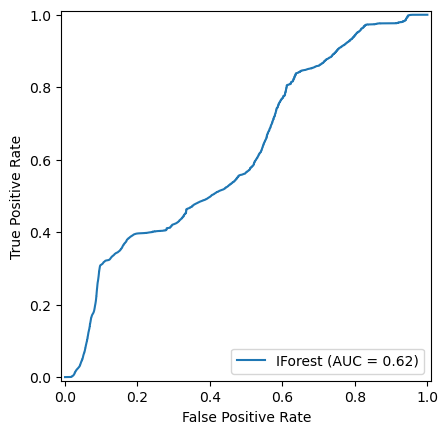

In [50]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

y_prob=iforest.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
displ = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="IForest")
displ.plot()
plt.show()

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(


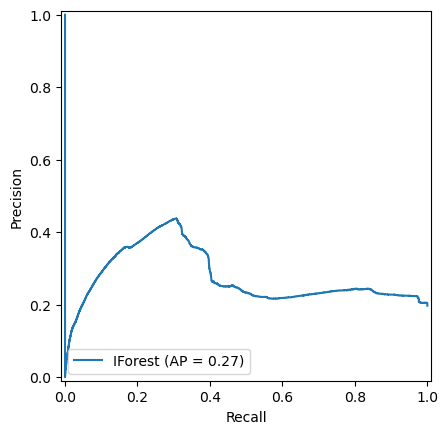

In [51]:
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
import matplotlib.pyplot as plt

y_prob=iforest.predict_proba(X_test)[:,1]
pre, rec, _ = precision_recall_curve(y_test, y_prob)
avg_pre = average_precision_score(y_test, y_prob)
disp=PrecisionRecallDisplay(precision=pre, recall=rec, average_precision=avg_pre, estimator_name="IForest")
disp.plot()
plt.show()

## 1.2.9 - Computing anomaly score 

In [52]:
anomaly_score=iforest.predict_proba(X_test)[:,1]

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


## 1.3 - Computing attack type score

### 1.3.1 - Loading the datasets

In [53]:
import numpy as np
import pandas as pd
df_train=pd.read_csv("./CSVs/merged/Train.csv")
df_test=pd.read_csv("./CSVs/merged/Test.csv")

### 1.3.2 - Categorical encoding for type mapping

In [54]:
df_dict_train={}
df_dict_test={}
attack_types=[label for label, value in df_train['Label'].value_counts().items() if label!='BENIGN' and value > 667]
print(attack_types)
for label in attack_types:
    df_dict_train[label]=label_encode(df_train, [label])
    df_dict_test[label]=label_encode(df_test, [label])

['DoS Hulk', 'PortScan', 'DDoS', 'DoS GoldenEye', 'FTP-Patator', 'SSH-Patator', 'DoS slowloris', 'DoS Slowhttptest', 'Bot', 'Web Attack \x96 Brute Force']


In [55]:
for label in attack_types:
    print(label)
    print("train set")
    print(df_dict_train[label]["Label"].value_counts())
    print("test set")
    print(df_dict_test[label]["Label"].value_counts())

DoS Hulk
train set
Label
0    1741773
1     154818
Name: count, dtype: int64
test set
Label
0    857897
1     76255
Name: count, dtype: int64
PortScan
train set
Label
0    1790108
1     106483
Name: count, dtype: int64
test set
Label
0    881705
1     52447
Name: count, dtype: int64
DDoS
train set
Label
0    1810813
1      85778
Name: count, dtype: int64
test set
Label
0    891903
1     42249
Name: count, dtype: int64
DoS GoldenEye
train set
Label
0    1889695
1       6896
Name: count, dtype: int64
test set
Label
0    930755
1      3397
Name: count, dtype: int64
FTP-Patator
train set
Label
0    1891273
1       5318
Name: count, dtype: int64
test set
Label
0    931532
1      2620
Name: count, dtype: int64
SSH-Patator
train set
Label
0    1892641
1       3950
Name: count, dtype: int64
test set
Label
0    932205
1      1947
Name: count, dtype: int64
DoS slowloris
train set
Label
0    1892708
1       3883
Name: count, dtype: int64
test set
Label
0    932239
1      1913
Name: count, dtype: 

### 1.3.3 - Feature removal

In [56]:
rm_cols=["Flow ID", "Source IP", "Destination IP", "Timestamp"]
for label in attack_types:
    df_dict_train[label] = df_dict_train[label].drop(rm_cols, axis=1)
    df_dict_test[label] = df_dict_test[label].drop(rm_cols, axis=1)
    df_dict_train[label].info()
    df_dict_test[label].info()

<class 'pandas.DataFrame'>
RangeIndex: 1896591 entries, 0 to 1896590
Data columns (total 81 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Source Port                  float64
 1   Destination Port             float64
 2   Protocol                     float64
 3   Flow Duration                float64
 4   Total Fwd Packets            float64
 5   Total Backward Packets       float64
 6   Total Length of Fwd Packets  float64
 7   Total Length of Bwd Packets  float64
 8   Fwd Packet Length Max        float64
 9   Fwd Packet Length Min        float64
 10  Fwd Packet Length Mean       float64
 11  Fwd Packet Length Std        float64
 12  Bwd Packet Length Max        float64
 13  Bwd Packet Length Min        float64
 14  Bwd Packet Length Mean       float64
 15  Bwd Packet Length Std        float64
 16  Flow Bytes/s                 float64
 17  Flow Packets/s               float64
 18  Flow IAT Mean                float64
 19  Flow IAT St

### 1.3.4 - Feature label separation

In [57]:
y_train_dict={}
X_train_dict={}
y_test_dict={}
X_test_dict={}

for label in attack_types:
    y_train_dict[label], X_train_dict[label]= df_dict_train[label]["Label"], df_dict_train[label].drop("Label", axis=1)
    y_test_dict[label], X_test_dict[label]= df_dict_test[label]["Label"], df_dict_test[label].drop("Label", axis=1)
    X_train_dict[label].info()
    X_test_dict[label].info()

<class 'pandas.DataFrame'>
RangeIndex: 1896591 entries, 0 to 1896590
Data columns (total 80 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Source Port                  float64
 1   Destination Port             float64
 2   Protocol                     float64
 3   Flow Duration                float64
 4   Total Fwd Packets            float64
 5   Total Backward Packets       float64
 6   Total Length of Fwd Packets  float64
 7   Total Length of Bwd Packets  float64
 8   Fwd Packet Length Max        float64
 9   Fwd Packet Length Min        float64
 10  Fwd Packet Length Mean       float64
 11  Fwd Packet Length Std        float64
 12  Bwd Packet Length Max        float64
 13  Bwd Packet Length Min        float64
 14  Bwd Packet Length Mean       float64
 15  Bwd Packet Length Std        float64
 16  Flow Bytes/s                 float64
 17  Flow Packets/s               float64
 18  Flow IAT Mean                float64
 19  Flow IAT St

### 1.3.5 - Train XGBoost type mappers

In [58]:
from xgboost import XGBClassifier
mapper_dict={}
for label in attack_types:
    xgboost=XGBClassifier(n_estimators=50, random_state=42)
    xgboost.fit(X_train_dict[label], y_train_dict[label])
    mapper_dict[label]=xgboost

### 1.3.6 - Test XGBoost type mappers

In [59]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
for label, xgboost in mapper_dict.items(): 
    y_pred=xgboost.predict(X_test_dict[label])
    acc=accuracy_score(y_test_dict[label], y_pred)
    print(f"xgboost test accuracy for {label}: {acc:.3f}")
    rec=recall_score(y_test_dict[label], y_pred)
    print(f"xgboost test recall for {label}: {rec:.3f}")
    rec=precision_score(y_test_dict[label], y_pred)
    print(f"xgboost test precision for {label}: {rec:.3f}")

xgboost test accuracy for DoS Hulk: 0.998
xgboost test recall for DoS Hulk: 0.973
xgboost test precision for DoS Hulk: 0.999
xgboost test accuracy for PortScan: 1.000
xgboost test recall for PortScan: 0.997
xgboost test precision for PortScan: 1.000
xgboost test accuracy for DDoS: 0.987
xgboost test recall for DDoS: 0.999
xgboost test precision for DDoS: 0.776
xgboost test accuracy for DoS GoldenEye: 1.000
xgboost test recall for DoS GoldenEye: 0.936
xgboost test precision for DoS GoldenEye: 0.967
xgboost test accuracy for FTP-Patator: 1.000
xgboost test recall for FTP-Patator: 0.997
xgboost test precision for FTP-Patator: 1.000
xgboost test accuracy for SSH-Patator: 1.000
xgboost test recall for SSH-Patator: 0.953
xgboost test precision for SSH-Patator: 1.000
xgboost test accuracy for DoS slowloris: 0.998
xgboost test recall for DoS slowloris: 0.375
xgboost test precision for DoS slowloris: 0.636
xgboost test accuracy for DoS Slowhttptest: 0.998
xgboost test recall for DoS Slowhttptes

### 1.3.7 - ROC curves for the mappers

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.wa

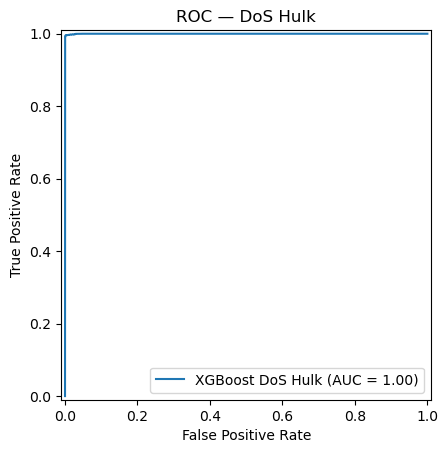

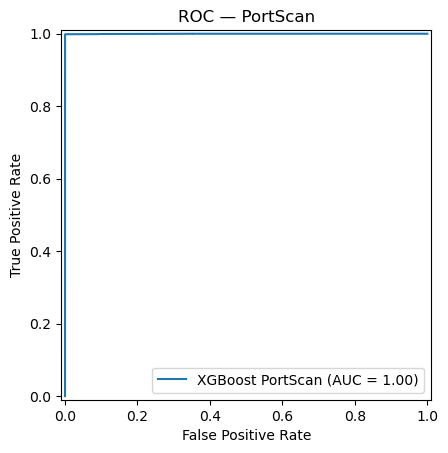

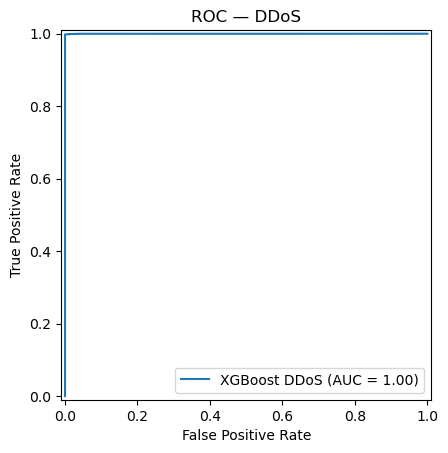

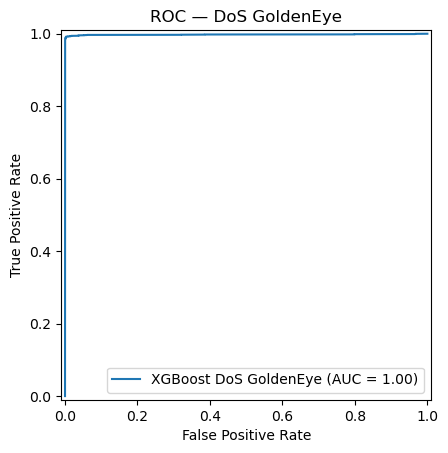

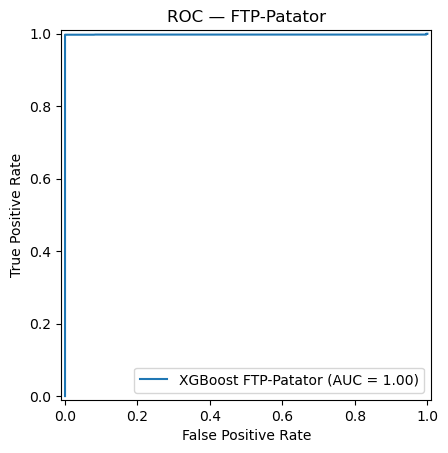

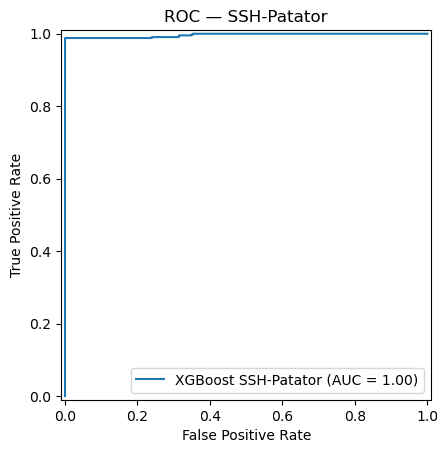

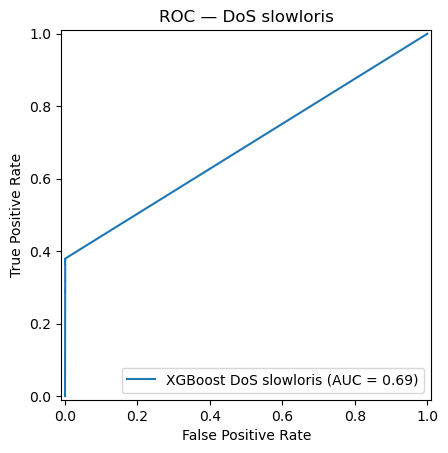

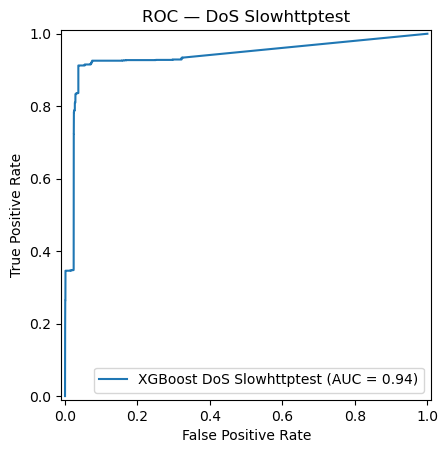

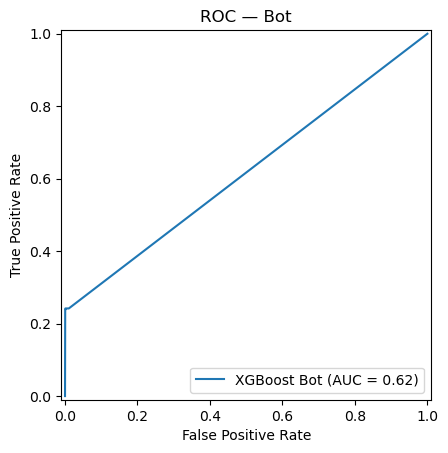

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


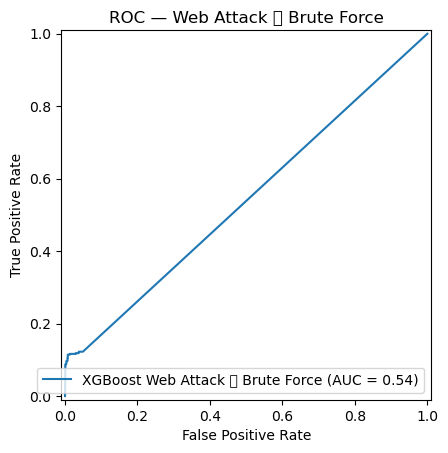

In [60]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

prob_dict={}

for label, xgboost in mapper_dict.items():
    y_prob = xgboost.predict_proba(X_test_dict[label])[:, 1]
    prob_dict[label]=y_prob
    
    fpr, tpr, _ = roc_curve(y_test_dict[label], y_prob)
    roc_auc = roc_auc_score(y_test_dict[label], y_prob)
    
    fig1, ax1 = plt.subplots()
    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="XGBoost "+label).plot(ax=ax1)
    ax1.set_title(f"ROC — {label}")

plt.show() 

### 1.3.8 - Precision-Recall curves for the mappers

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warnings.warn(
/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.8 and will be removed in 1.10. Use `name` instead.
  warning

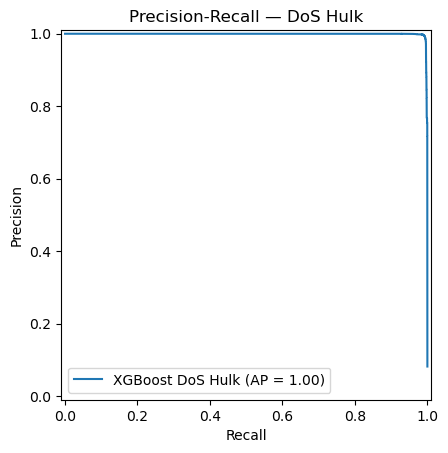

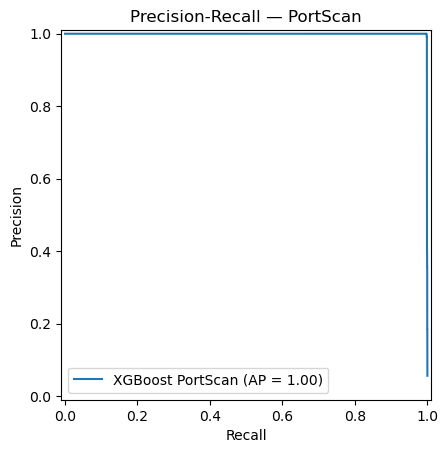

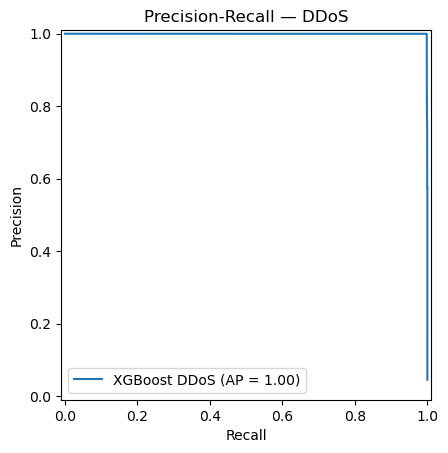

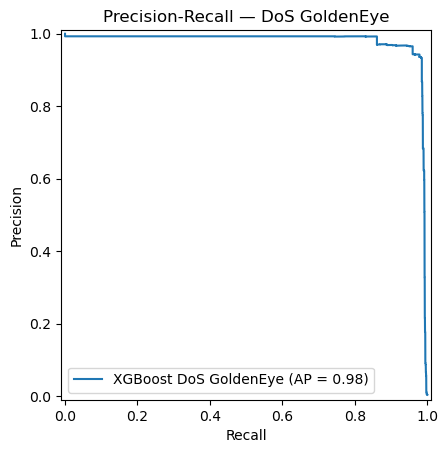

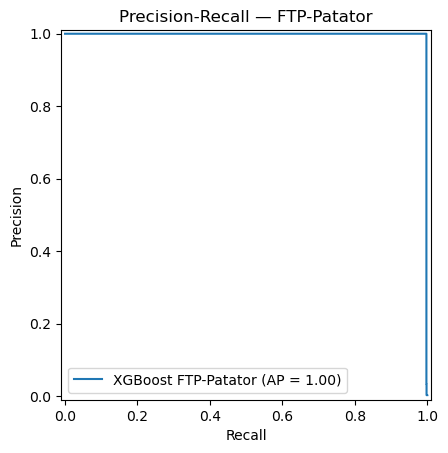

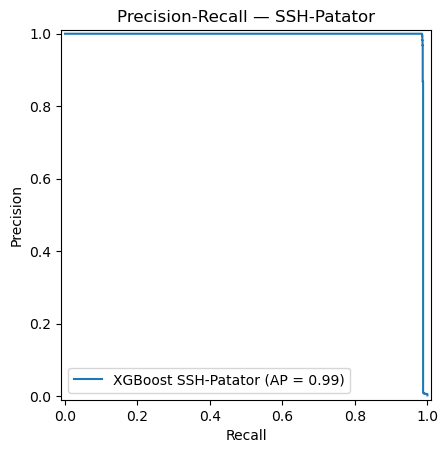

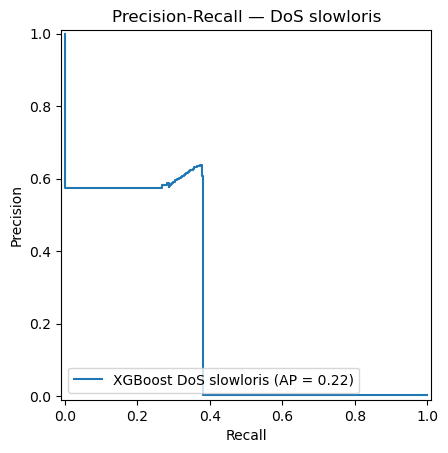

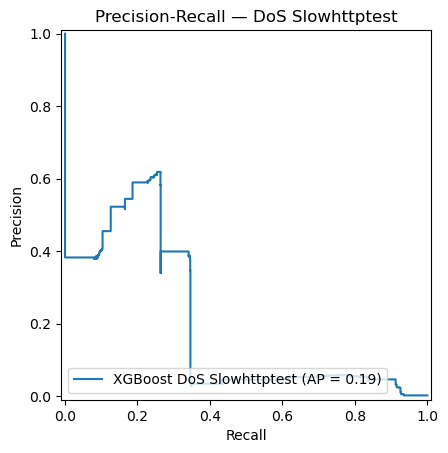

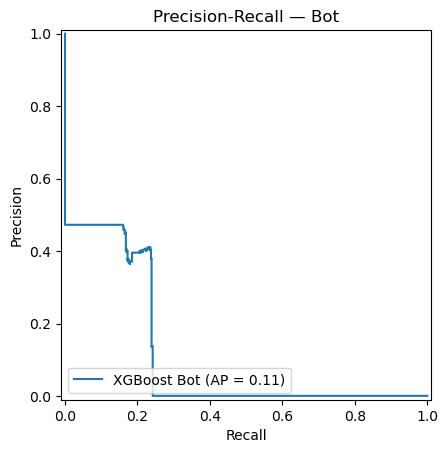

/home/users/davide.zhang/miniconda3/envs/attack_scenario_reconstruction/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


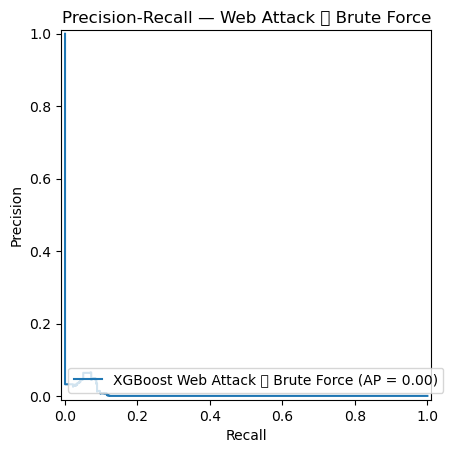

In [61]:
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
import matplotlib.pyplot as plt

for label, xgboost in mapper_dict.items():
    y_prob = xgboost.predict_proba(X_test_dict[label])[:, 1]
    prob_dict[label]=y_prob
    
    pre, rec, _ = precision_recall_curve(y_test_dict[label], y_prob)
    avg_pre = average_precision_score(y_test_dict[label], y_prob)
    
    fig2, ax2 = plt.subplots()
    PrecisionRecallDisplay(precision=pre, recall=rec, average_precision=avg_pre, estimator_name="XGBoost "+label).plot(ax=ax2)
    ax2.set_title(f"Precision-Recall — {label}")

plt.show() 

### 1.3.9 - Computing attack type score

In [62]:
attack_type_prob={}
for label, xgboost in mapper_dict.items():
    y_prob = xgboost.predict_proba(X_test_dict[label])[:, 1]
    attack_type_prob[label]=y_prob

## 1.4 - Building the scenario reconstruction dataset

### 1.4.1 - Loading the starting dataset 

In [63]:
import numpy as np
import pandas as pd
df_rec=pd.read_csv("./CSVs/merged/Test.csv")

### 1.4.2 - Extracting reconstruction features

In [64]:
rec_cols=["Flow ID", "Source IP", "Source Port", "Destination IP", "Destination Port", "Protocol", "Timestamp", "Flow Duration"]
df_rec=df_rec[["Flow ID", "Source IP", "Source Port", "Destination IP", "Destination Port",  "Protocol", "Timestamp", "Flow Duration"]]

### 1.4.3 - Adding new features

In [65]:
df_rec["Anomaly Score"]=anomaly_score
for attack_type, type_prob in attack_type_prob.items():
    df_rec[attack_type]=type_prob
df_rec.info()

<class 'pandas.DataFrame'>
RangeIndex: 934152 entries, 0 to 934151
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Flow ID                   934152 non-null  str    
 1   Source IP                 934152 non-null  str    
 2   Source Port               934152 non-null  float64
 3   Destination IP            934152 non-null  str    
 4   Destination Port          934152 non-null  float64
 5   Protocol                  934152 non-null  float64
 6   Timestamp                 934152 non-null  str    
 7   Flow Duration             934152 non-null  float64
 8   Anomaly Score             934152 non-null  float64
 9   DoS Hulk                  934152 non-null  float32
 10  PortScan                  934152 non-null  float32
 11  DDoS                      934152 non-null  float32
 12  DoS GoldenEye             934152 non-null  float32
 13  FTP-Patator               934152 non-null  float32
 14 

### 1.4.4 - Saving the dataset 

In [66]:
import pandas as pd
df_rec.to_csv("./CSVs/merged/Rec_dataset.csv",index=False)